# Weekly AQI Change Prediction
Goal: Given air quality and weather data from adjacent cities in the US over a period of time, predict whether the air quality index (AQI) will increase or decrease in the following week.

### Dataset
The data for this project was obtained from the U.S. Environmental Protection Agency (EPA) via the Air Data on AWS (EDAP) public portal. ([Direct Access Portal](https://awsedap.epa.gov/public/single/?appid=efa6d1bf-4cab-4e17-9e14-8046adfe9249&sheet=3495c3da-aca4-494b-a1d8-d6d6a0571cbc&opt=currsel%2ctxmenu&bookmark=6ebdada3-18f6-4831-a4b6-9d6e1a14a446))

**Time Period:** 01/01/2025 till 31/12/2025 

**Data Types:**
- Meteorological - Hourly
- PM2.5 - Hourly 
- Ozone - Hourly

**Station Selection:**
| State | Selected Monitoring Stations
|-------|--------|
| California | LPO010 |
| Texas | ACL188, PAL190 |
| New York | NIC001, WFM105 |
| Illinois | BVL130, STK130 |
| Florida | IRL141, CNS011 |
| Colorado | GTH161, ROM206 |

Note on California: Station LPO010 was the only one in the selected region that provided a complete and consistent hourly record for all three required data types (particularly PM2.5) within the chosen timeframe. Therefore, it was selected as the sole representative for this state.

In [39]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Data Loading and Preprocessing
- Loading Individual Datasets
- Concatenating DataFrames
- Merging into a Single Master DataFrame

In [42]:
data_path = "dataset/"
all_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]

list_of_met_dfs = []
list_of_oz_dfs = []
list_of_pm_dfs = []

for filename in all_files:
    state = filename.split('_')[0]
    data_type = filename.split('_')[1].replace('.csv', '')
    file_path = os.path.join(data_path, filename)
    
    df = pd.read_csv(file_path, na_values=['-'])
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    df['state'] = state.upper()

    if data_type == 'met':
        df = df.rename(columns={'site_id': 'site_id', 'dateon': 'timestamp'})
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%m/%d/%Y %I:%M:%S %p')
        df = df[['site_id', 'timestamp', 'state', 'precipitation', 'ozone', 'relative_humidity', 'temperature', 'wind_direction', 'wind_speed']]
        list_of_met_dfs.append(df)
        
    elif data_type == 'oz':
        df = df.rename(columns={'site_id': 'site_id', 'selected_date_time': 'timestamp'})
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%m/%d/%Y %I:%M:%S %p')
        df = df.rename(columns={'ozone': 'ozone_ppb'})
        df = df[['site_id', 'timestamp', 'ozone_ppb']]
        list_of_oz_dfs.append(df)
        
    elif data_type == 'pm':
        df = df.rename(columns={'site_id': 'site_id', 'selected_date_time': 'timestamp', 'pm2.5_(µg/m³)': 'pm2_5'})
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%m/%d/%Y %I:%M:%S %p')
        df = df[['site_id', 'timestamp', 'pm2_5']]
        list_of_pm_dfs.append(df)

print("Finished loading all files.")

Finished loading all files.


In [45]:
met_df = pd.concat(list_of_met_dfs, ignore_index=True) if list_of_met_dfs else pd.DataFrame()
oz_df = pd.concat(list_of_oz_dfs, ignore_index=True) if list_of_oz_dfs else pd.DataFrame()
pm_df = pd.concat(list_of_pm_dfs, ignore_index=True) if list_of_pm_dfs else pd.DataFrame()

print(f"Meteorological data shape: {met_df.shape}")
print(f"Ozone data shape: {oz_df.shape}")
print(f"PM2.5 data shape: {pm_df.shape}")

Meteorological data shape: (81292, 9)
Ozone data shape: (73403, 3)
PM2.5 data shape: (56828, 3)


In [49]:
final_df = met_df
final_df = pd.merge(final_df, pm_df, on=['site_id', 'timestamp'], how='outer')
final_df = pd.merge(final_df, oz_df, on=['site_id', 'timestamp'], how='outer')

final_df = final_df.sort_values(by=['site_id', 'timestamp']).reset_index(drop=True)
final_df['state'] = final_df.groupby('site_id')['state'].ffill().bfill() # Forward and backward fill state for merged rows
final_df = final_df.drop_duplicates(subset=['site_id', 'timestamp'])

print(f"Dimensions of the final DataFrame: {final_df.shape}")
print("\nInfo of the final DataFrame:")
final_df.info()

Dimensions of the final DataFrame: (89495, 11)

Info of the final DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 89495 entries, 0 to 699143
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   site_id            89495 non-null  object        
 1   timestamp          89484 non-null  datetime64[ns]
 2   state              89495 non-null  object        
 3   precipitation      12023 non-null  float64       
 4   ozone              58239 non-null  float64       
 5   relative_humidity  14442 non-null  float64       
 6   temperature        73457 non-null  float64       
 7   wind_direction     14444 non-null  float64       
 8   wind_speed         14444 non-null  float64       
 9   pm2_5              1884 non-null   float64       
 10  ozone_ppb          56652 non-null  float64       
dtypes: datetime64[ns](1), float64(8), object(2)
memory usage: 8.2+ MB


### Calculate AQI
The Air Quality Index (AQI) is not directly provided in the data that was used. We must calculate it from the pollutant concentrations (PM2.5 and Ozone). This process translates raw concentration values into a standardized index from 0 to 500. We use the official U.S. EPA breakpoint tables and linear interpolation formula.

Source: [AQI Technical Assistance Document](https://www.airnow.gov/sites/default/files/2020-05/aqi-technical-assistance-document-sept2018.pdf)

The final AQI for any given hour is the maximum of the individual AQIs calculated for each pollutant.

In [51]:
pm25_breakpoints = [
    (0.0, 12.0, 0, 50), (12.1, 35.4, 51, 100), (35.5, 55.4, 101, 150),
    (55.5, 150.4, 151, 200), (150.5, 250.4, 201, 300), (250.5, 350.4, 301, 400),
    (350.5, 500.4, 401, 500)
]

ozone_breakpoints = [
    (0, 54, 0, 50), (55, 70, 51, 100), (71, 85, 101, 150),
    (86, 105, 151, 200), (106, 200, 201, 300)
]

def calculate_single_aqi(concentration, breakpoints):
    if pd.isna(concentration) or concentration < 0:
        return np.nan
    for c_low, c_high, i_low, i_high in breakpoints:
        if c_low <= concentration <= c_high:
            aqi = ((i_high - i_low) / (c_high - c_low)) * (concentration - c_low) + i_low
            return round(aqi)
    if concentration > breakpoints[-1][1]:
        return breakpoints[-1][3]
    return np.nan

print("Calculating individual AQI for PM2.5...")
final_df['aqi_pm2_5'] = final_df['pm2_5'].apply(lambda x: calculate_single_aqi(x, pm25_breakpoints))

print("Calculating individual AQI for Ozone...")
final_df['aqi_ozone'] = final_df['ozone_ppb'].apply(lambda x: calculate_single_aqi(x, ozone_breakpoints))

print("Determining the final hourly AQI...")
final_df['aqi'] = final_df[['aqi_pm2_5', 'aqi_ozone']].max(axis=1)

print("\nAQI calculation complete. Preview:")
print(final_df[['site_id', 'timestamp', 'pm2_5', 'aqi_pm2_5', 'ozone_ppb', 'aqi_ozone', 'aqi']].head())

Calculating individual AQI for PM2.5...
Calculating individual AQI for Ozone...
Determining the final hourly AQI...

AQI calculation complete. Preview:
  site_id           timestamp  pm2_5  aqi_pm2_5  ozone_ppb  aqi_ozone   aqi
0  ALC188 2025-01-01 00:00:00    NaN        NaN       12.0       11.0  11.0
1  ALC188 2025-01-01 01:00:00    NaN        NaN        8.0        7.0   7.0
2  ALC188 2025-01-01 02:00:00    NaN        NaN        NaN        NaN   NaN
3  ALC188 2025-01-01 03:00:00    NaN        NaN       18.0       17.0  17.0
4  ALC188 2025-01-01 04:00:00    NaN        NaN       18.0       17.0  17.0


### Exploring Data

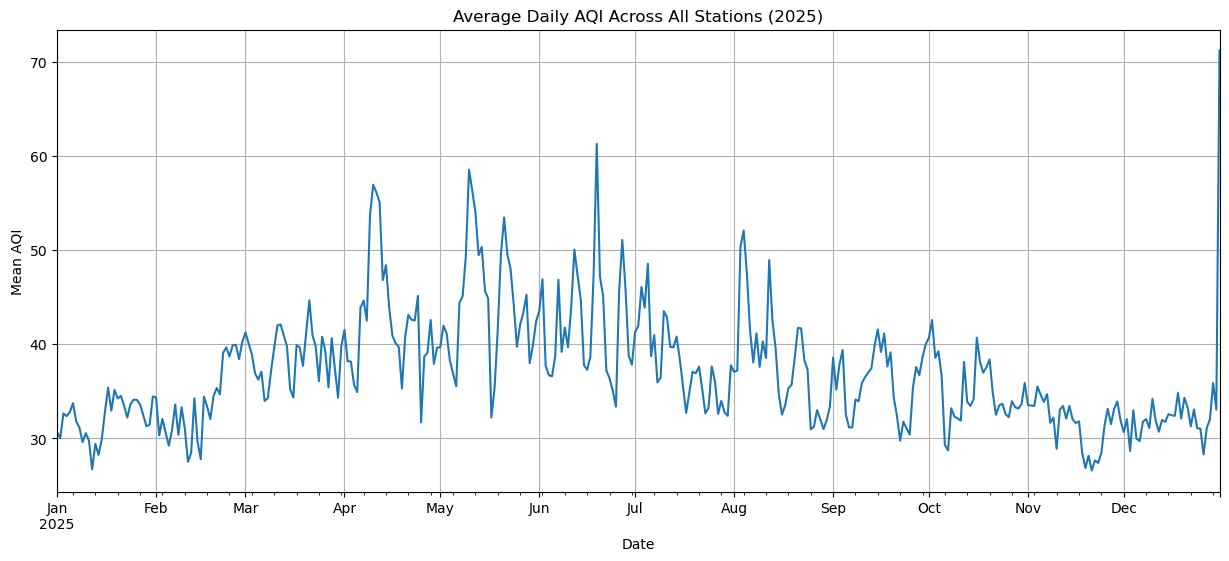

In [ ]:
plt.figure(figsize=(15, 6))
final_df.set_index('timestamp')['aqi'].resample('D').mean().plot()
plt.title('Average Daily AQI Across All Stations (2025)')
plt.ylabel('Mean AQI')
plt.xlabel('Date')
plt.grid(True)
plt.show()

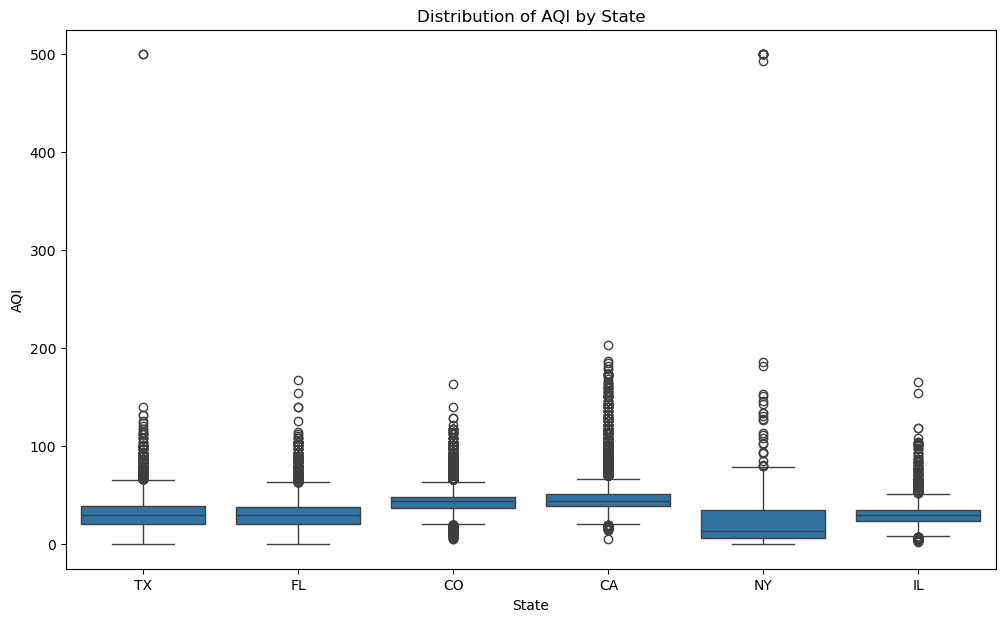

In [64]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='state', y='aqi', data=final_df)
plt.title('Distribution of AQI by State')
plt.ylabel('AQI')
plt.xlabel('State')
plt.show()

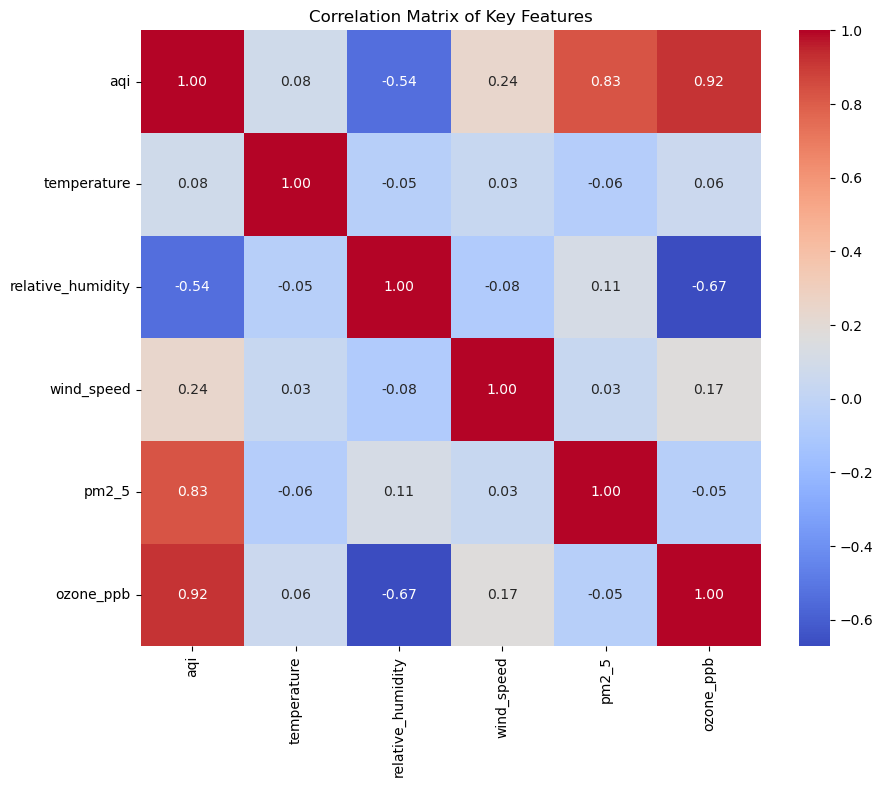

In [65]:
plt.figure(figsize=(10, 8))
corr_df = final_df[['aqi', 'temperature', 'relative_humidity', 'wind_speed', 'pm2_5', 'ozone_ppb']].corr()
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Features')
plt.show()

### Define Targetvariable
The project goal is to predict if the AQI will increase or decrease in the following week. To prepare the data for this, we must:

- Aggregate Data Weekly: Convert our hourly data into a weekly summary, using the mean for each feature.
- Create the Target: For each week, we'll create a target variable target_aqi_increase which is 1 if the next week's average AQI is higher than the current week's, and 0 otherwise.

This transforms the problem into a binary classification task.

In [ ]:
aggregation_rules = {
    'aqi': 'mean',
    'temperature': 'mean',
    'pm2_5': 'mean',
    'relative_humidity': 'mean',
    'wind_speed': 'mean',
    'precipitation': 'mean'
}

weekly_df = final_df.groupby(['site_id', pd.Grouper(key='timestamp', freq='W')]).agg(aggregation_rules)
weekly_df = weekly_df.rename(columns={
    'aqi': 'weekly_avg_aqi',
    'temperature': 'weekly_avg_temp',
    'pm2_5': 'weekly_avg_pm2_5',
    'relative_humidity': 'weekly_avg_humidity',
    'wind_speed': 'weekly_avg_wind',
    'precipitation': 'weekly_avg_precip'
})

print("Preview of the weekly DataFrame:")
print(weekly_df.head())

weekly_df['next_week_aqi'] = weekly_df.groupby('site_id')['weekly_avg_aqi'].shift(-1)
weekly_df = weekly_df.dropna(subset=['next_week_aqi'])
weekly_df['target_aqi_increase'] = (weekly_df['next_week_aqi'] > weekly_df['weekly_avg_aqi']).astype(int)
ml_ready_df = weekly_df.drop(columns=['next_week_aqi']).reset_index()

print("\nPreview of the final DataFrame ready for machine learning:")
print(ml_ready_df.head())

print("\nDistribution of the target variable:")
print(ml_ready_df['target_aqi_increase'].value_counts())

Preview of the weekly DataFrame:
                    weekly_avg_aqi  ...  weekly_avg_precip
site_id timestamp                   ...                   
ALC188  2025-01-05       22.843478  ...                NaN
        2025-01-12       23.287500  ...                NaN
        2025-01-19       24.230216  ...                NaN
        2025-01-26       29.391667  ...                NaN
        2025-02-02       24.930380  ...                NaN

[5 rows x 6 columns]

Preview of the final DataFrame ready for machine learning:
  site_id  timestamp  ...  weekly_avg_precip  target_aqi_increase
0  ALC188 2025-01-05  ...                NaN                    1
1  ALC188 2025-01-12  ...                NaN                    1
2  ALC188 2025-01-19  ...                NaN                    1
3  ALC188 2025-01-26  ...                NaN                    0
4  ALC188 2025-02-02  ...                NaN                    0

[5 rows x 9 columns]

Distribution of the target variable:
target_aqi_incre

### Model Training and Evaluation
- Feature and Target Selection
- Time-Based Train-Test Split
- Model Training
- Prediction and Evaluation
- Feature Importance Analysis

In [67]:
y = ml_ready_df['target_aqi_increase']
X = ml_ready_df.drop(columns=['site_id', 'timestamp', 'target_aqi_increase'])

print("\nDimensions of Features (X):", X.shape)
print("Dimensions of Target (y):", y.shape)

ml_ready_df_sorted = ml_ready_df.sort_values(by='timestamp').reset_index(drop=True)

y = ml_ready_df_sorted['target_aqi_increase']
X = ml_ready_df_sorted.drop(columns=['site_id', 'timestamp', 'target_aqi_increase'])

split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"\nData split:")
print(f"Training data: {len(X_train)} weeks")
print(f"Test data: {len(X_test)} weeks")


Dimensions of Features (X): (482, 6)
Dimensions of Target (y): (482,)

Data split:
Training data: 385 weeks
Test data: 97 weeks



Model Evaluation Results

Accuracy: 52.58%

Classification Report:
                     precision    recall  f1-score   support

Decrease/Stable (0)       0.55      0.35      0.42        49
       Increase (1)       0.52      0.71      0.60        48

           accuracy                           0.53        97
          macro avg       0.53      0.53      0.51        97
       weighted avg       0.53      0.53      0.51        97


Confusion Matrix:


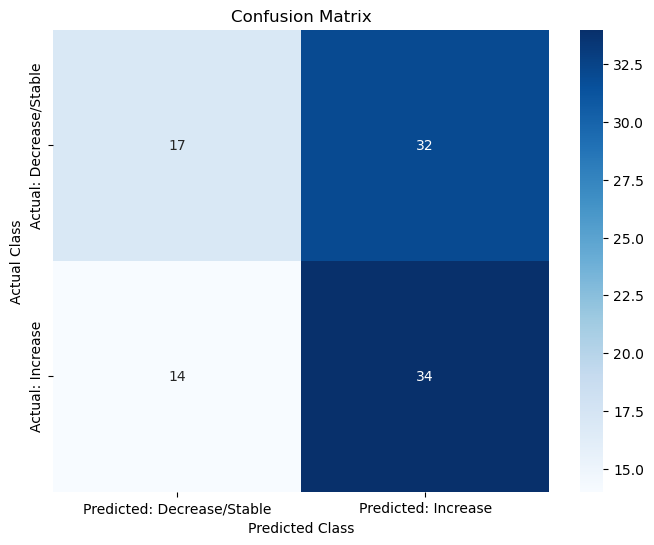

In [68]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel Evaluation Results")

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Decrease/Stable (0)', 'Increase (1)']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Decrease/Stable', 'Predicted: Increase'],
            yticklabels=['Actual: Decrease/Stable', 'Actual: Increase'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

In [69]:
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importance Ranking")
print(feature_importance_df)


Feature Importance Ranking
               Feature  Importance
0       weekly_avg_aqi    0.412443
1      weekly_avg_temp    0.311596
2     weekly_avg_pm2_5    0.197275
3  weekly_avg_humidity    0.029236
4      weekly_avg_wind    0.028499
5    weekly_avg_precip    0.020950


### Visualization

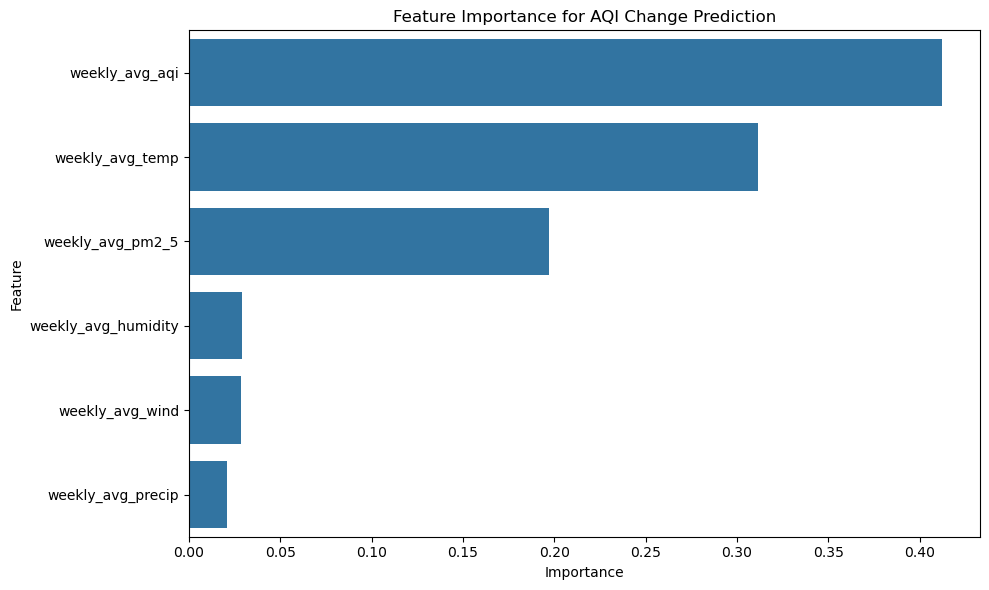

In [62]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for AQI Change Prediction')
plt.tight_layout()
plt.show()

### Discussion

Summary of Findings: 

The Random Forest model was able to predict a weekly increase in AQI with an accuracy of 52.58%. The most important features for this prediction were the previous week's AQI and temperature, suggesting that high-pollution events are often persistent and linked to specific weather conditions.

Limitations: 
- Data Granularity: The model uses weekly averages. This aggregation might smooth out important short-term events (e.g. a sudden spike in pollution for 24 hours) that could influence the following week.
- Feature Scope: The analysis is limited to the provided weather and pollutant data. It does not include other potentially crucial factors like traffic volume, industrial activity, or large-scale events like wildfires, which can significantly impact air quality.
- Geographic Scope: The model was trained on data from specific US states. Its performance in other regions with different climates or pollution sources (e.g. Europe or Asia) is not guaranteed.

Future Work: 
- To improve performance, future work could incorporate additional data sources, such as wildfire smoke plumes or traffic data.
- Experimenting with more advanced time-series models like LSTMs or GRUs, which can capture temporal dependencies more effectively, could yield better results.
- A more granular prediction (e.g. daily AQI changes) could be explored as a next step.
